<a href="https://colab.research.google.com/github/Alex-Roberts27/Research_Mock_DB62_EW46_RnaSeqPlots/blob/main/DB62VsEW46heatmaps%2Bvolcanos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 7.6 MB/s eta 0:00:00


In [2]:
counts = pd.read_excel('RNA-seq-matrix-for-efra.xlsx')
counts

,gene_id,gene_name,gene_biotype,HT-1080_Mock_1_cpm,HT-1080_Mock_1_count,HT-1080_Mock_2_cpm,HT-1080_Mock_2_count,HT-1080_DB62_1_cpm,HT-1080_DB62_1_count,HT-1080_DB62_2_cpm,HT-1080_DB62_2_count,HT-1080_EW46_1_cpm,HT-1080_EW46_1_count,HT-1080_EW46_2_cpm,HT-1080_EW46_2_count
0,ENSG00000000003,TSPAN6,protein_coding,18.845070,211.67,21.288051,259.33,16.962117,180.17,15.801986,161.17,20.766109,229.33,14.515106,171.25
1,ENSG00000000005,TNMD,protein_coding,0.000000,0.00,0.082089,1.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
2,ENSG00000000419,DPM1,protein_coding,146.989231,1651.00,165.326550,2014.00,170.873301,1815.00,171.383456,1748.00,152.578787,1685.00,162.060629,1912.00
3,ENSG00000000457,SCYL3,protein_coding,6.766312,76.00,6.074560,74.00,6.307720,67.00,6.372955,65.00,5.342521,59.00,6.526500,77.00
4,ENSG00000000460,FIRRM,protein_coding,9.971408,112.00,11.738678,143.00,11.768134,125.00,10.196727,104.00,8.602365,95.00,12.459682,147.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78981,ERCC-00164,ERCC-00164,transgene,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78982,ERCC-00165,ERCC-00165,transgene,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78983,ERCC-00168,ERCC-00168,transgene,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78984,ERCC-00170,ERCC-00170,transgene,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00


In [3]:
# Load the Excel file
# Use sheet_name=None to load all sheets, or specify one (e.g., sheet_name=0)
df = pd.read_excel('RNA-seq-matrix-for-efra.xlsx')

# Convert and save as CSV
# index=False prevents pandas from adding an extra column for row numbers
df.to_csv('RNA-seq-matrix-for-efra.csv', index=False)


In [4]:
'''specific_genes = [
    'Rps29', 'Ctsd', 'Gstp1', 'Gapdh', 'H2az1', 'Vim', 'H2az2',
    'Snrpf', 'Akr1c3', 'Akr1c1', 'Snrpb', 'Eif4a1', 'Pkm', 'Rack1',
    'Tpi1', 'Akr1c2', 'Hspa8', 'Tkt', 'Ube2i', 'Aldoa'
]
missing_genes = [gene for gene in specific_genes if gene not in counts.index]
if missing_genes:
    print(f"Warning: The following genes were not found in the dataset and will not be included in the heatmap: {missing_genes}")
else:
    print("Good")'''

#Was for specific genes not useful now

'specific_genes = [\n    \'Rps29\', \'Ctsd\', \'Gstp1\', \'Gapdh\', \'H2az1\', \'Vim\', \'H2az2\',\n    \'Snrpf\', \'Akr1c3\', \'Akr1c1\', \'Snrpb\', \'Eif4a1\', \'Pkm\', \'Rack1\',\n    \'Tpi1\', \'Akr1c2\', \'Hspa8\', \'Tkt\', \'Ube2i\', \'Aldoa\'\n]\nmissing_genes = [gene for gene in specific_genes if gene not in counts.index]\nif missing_genes:\n    print(f"Warning: The following genes were not found in the dataset and will not be included in the heatmap: {missing_genes}")\nelse:\n    print("Good")'

In [5]:
counts = pd.read_csv('RNA-seq-matrix-for-efra.csv')
counts

,gene_id,gene_name,gene_biotype,HT-1080_Mock_1_cpm,HT-1080_Mock_1_count,HT-1080_Mock_2_cpm,HT-1080_Mock_2_count,HT-1080_DB62_1_cpm,HT-1080_DB62_1_count,HT-1080_DB62_2_cpm,HT-1080_DB62_2_count,HT-1080_EW46_1_cpm,HT-1080_EW46_1_count,HT-1080_EW46_2_cpm,HT-1080_EW46_2_count
0,ENSG00000000003,TSPAN6,protein_coding,18.845070,211.67,21.288051,259.33,16.962117,180.17,15.801986,161.17,20.766109,229.33,14.515106,171.25
1,ENSG00000000005,TNMD,protein_coding,0.000000,0.00,0.082089,1.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
2,ENSG00000000419,DPM1,protein_coding,146.989231,1651.00,165.326550,2014.00,170.873301,1815.00,171.383456,1748.00,152.578787,1685.00,162.060629,1912.00
3,ENSG00000000457,SCYL3,protein_coding,6.766312,76.00,6.074560,74.00,6.307720,67.00,6.372955,65.00,5.342521,59.00,6.526500,77.00
4,ENSG00000000460,FIRRM,protein_coding,9.971408,112.00,11.738678,143.00,11.768134,125.00,10.196727,104.00,8.602365,95.00,12.459682,147.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78981,ERCC-00164,ERCC-00164,transgene,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78982,ERCC-00165,ERCC-00165,transgene,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78983,ERCC-00168,ERCC-00168,transgene,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78984,ERCC-00170,ERCC-00170,transgene,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00


In [6]:
# if the gene_biotype is not protein_coding, remove it from the sheet
counts = counts[counts.gene_biotype == 'protein_coding']
counts

,gene_id,gene_name,gene_biotype,HT-1080_Mock_1_cpm,HT-1080_Mock_1_count,HT-1080_Mock_2_cpm,HT-1080_Mock_2_count,HT-1080_DB62_1_cpm,HT-1080_DB62_1_count,HT-1080_DB62_2_cpm,HT-1080_DB62_2_count,HT-1080_EW46_1_cpm,HT-1080_EW46_1_count,HT-1080_EW46_2_cpm,HT-1080_EW46_2_count
0,ENSG00000000003,TSPAN6,protein_coding,18.845070,211.67,21.288051,259.33,16.962117,180.17,15.801986,161.17,20.766109,229.33,14.515106,171.25
1,ENSG00000000005,TNMD,protein_coding,0.000000,0.00,0.082089,1.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
2,ENSG00000000419,DPM1,protein_coding,146.989231,1651.00,165.326550,2014.00,170.873301,1815.00,171.383456,1748.00,152.578787,1685.00,162.060629,1912.00
3,ENSG00000000457,SCYL3,protein_coding,6.766312,76.00,6.074560,74.00,6.307720,67.00,6.372955,65.00,5.342521,59.00,6.526500,77.00
4,ENSG00000000460,FIRRM,protein_coding,9.971408,112.00,11.738678,143.00,11.768134,125.00,10.196727,104.00,8.602365,95.00,12.459682,147.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78884,ENSG00000310558,NaN,protein_coding,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78886,ENSG00000310560,PAXX,protein_coding,25.373671,285.00,19.208745,234.00,19.488029,207.00,21.570000,220.00,22.275597,246.00,21.613734,255.00
78887,ENSG00000310561,NaN,protein_coding,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78888,ENSG00000310562,NaN,protein_coding,0.089030,1.00,0.246266,3.00,0.188290,2.00,0.000000,0.00,0.000000,0.00,0.169519,2.00


In [7]:
#remove the gene_name column
counts = counts.drop(columns=['gene_name'])
counts
#remove the gene_biotype column
counts = counts.drop(columns=['gene_biotype'])
counts

,gene_id,HT-1080_Mock_1_cpm,HT-1080_Mock_1_count,HT-1080_Mock_2_cpm,HT-1080_Mock_2_count,HT-1080_DB62_1_cpm,HT-1080_DB62_1_count,HT-1080_DB62_2_cpm,HT-1080_DB62_2_count,HT-1080_EW46_1_cpm,HT-1080_EW46_1_count,HT-1080_EW46_2_cpm,HT-1080_EW46_2_count
0,ENSG00000000003,18.845070,211.67,21.288051,259.33,16.962117,180.17,15.801986,161.17,20.766109,229.33,14.515106,171.25
1,ENSG00000000005,0.000000,0.00,0.082089,1.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
2,ENSG00000000419,146.989231,1651.00,165.326550,2014.00,170.873301,1815.00,171.383456,1748.00,152.578787,1685.00,162.060629,1912.00
3,ENSG00000000457,6.766312,76.00,6.074560,74.00,6.307720,67.00,6.372955,65.00,5.342521,59.00,6.526500,77.00
4,ENSG00000000460,9.971408,112.00,11.738678,143.00,11.768134,125.00,10.196727,104.00,8.602365,95.00,12.459682,147.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
78884,ENSG00000310558,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78886,ENSG00000310560,25.373671,285.00,19.208745,234.00,19.488029,207.00,21.570000,220.00,22.275597,246.00,21.613734,255.00
78887,ENSG00000310561,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00,0.000000,0.00
78888,ENSG00000310562,0.089030,1.00,0.246266,3.00,0.188290,2.00,0.000000,0.00,0.000000,0.00,0.169519,2.00


In [8]:
columns_to_drop = [
    'HT-1080_Mock_1_cpm',
    'HT-1080_Mock_2_cpm',
    'HT-1080_DB62_1_cpm',
    'HT-1080_DB62_2_cpm',
    'HT-1080_EW46_1_cpm',
    'HT-1080_EW46_2_cpm'
]
counts = counts.drop(columns=columns_to_drop)
counts

,gene_id,HT-1080_Mock_1_count,HT-1080_Mock_2_count,HT-1080_DB62_1_count,HT-1080_DB62_2_count,HT-1080_EW46_1_count,HT-1080_EW46_2_count
0,ENSG00000000003,211.67,259.33,180.17,161.17,229.33,171.25
1,ENSG00000000005,0.00,1.00,0.00,0.00,0.00,0.00
2,ENSG00000000419,1651.00,2014.00,1815.00,1748.00,1685.00,1912.00
3,ENSG00000000457,76.00,74.00,67.00,65.00,59.00,77.00
4,ENSG00000000460,112.00,143.00,125.00,104.00,95.00,147.00
...,...,...,...,...,...,...,...
78884,ENSG00000310558,0.00,0.00,0.00,0.00,0.00,0.00
78886,ENSG00000310560,285.00,234.00,207.00,220.00,246.00,255.00
78887,ENSG00000310561,0.00,0.00,0.00,0.00,0.00,0.00
78888,ENSG00000310562,1.00,3.00,2.00,0.00,0.00,2.00


In [9]:
counts = counts.set_index('gene_id')
counts

,HT-1080_Mock_1_count,HT-1080_Mock_2_count,HT-1080_DB62_1_count,HT-1080_DB62_2_count,HT-1080_EW46_1_count,HT-1080_EW46_2_count
gene_id,,,,,,
ENSG00000000003,211.67,259.33,180.17,161.17,229.33,171.25
ENSG00000000005,0.00,1.00,0.00,0.00,0.00,0.00
ENSG00000000419,1651.00,2014.00,1815.00,1748.00,1685.00,1912.00
ENSG00000000457,76.00,74.00,67.00,65.00,59.00,77.00
ENSG00000000460,112.00,143.00,125.00,104.00,95.00,147.00
...,...,...,...,...,...,...
ENSG00000310558,0.00,0.00,0.00,0.00,0.00,0.00
ENSG00000310560,285.00,234.00,207.00,220.00,246.00,255.00
ENSG00000310561,0.00,0.00,0.00,0.00,0.00,0.00


In [10]:
numeric_columns = counts.select_dtypes(include=['number']).columns
counts = counts[counts[numeric_columns].sum(axis=1) > 0]
counts

,HT-1080_Mock_1_count,HT-1080_Mock_2_count,HT-1080_DB62_1_count,HT-1080_DB62_2_count,HT-1080_EW46_1_count,HT-1080_EW46_2_count
gene_id,,,,,,
ENSG00000000003,211.67,259.33,180.17,161.17,229.33,171.25
ENSG00000000005,0.00,1.00,0.00,0.00,0.00,0.00
ENSG00000000419,1651.00,2014.00,1815.00,1748.00,1685.00,1912.00
ENSG00000000457,76.00,74.00,67.00,65.00,59.00,77.00
ENSG00000000460,112.00,143.00,125.00,104.00,95.00,147.00
...,...,...,...,...,...,...
ENSG00000310517,2207.50,2461.50,2048.00,2170.00,2375.50,2465.00
ENSG00000310525,24.50,34.50,26.50,26.50,22.50,21.00
ENSG00000310560,285.00,234.00,207.00,220.00,246.00,255.00


In [11]:
sig_counts = counts[~(counts < 10).all(axis=1)]
sig_counts

,HT-1080_Mock_1_count,HT-1080_Mock_2_count,HT-1080_DB62_1_count,HT-1080_DB62_2_count,HT-1080_EW46_1_count,HT-1080_EW46_2_count
gene_id,,,,,,
ENSG00000000003,211.67,259.33,180.17,161.17,229.33,171.25
ENSG00000000419,1651.00,2014.00,1815.00,1748.00,1685.00,1912.00
ENSG00000000457,76.00,74.00,67.00,65.00,59.00,77.00
ENSG00000000460,112.00,143.00,125.00,104.00,95.00,147.00
ENSG00000001036,658.00,772.00,604.00,562.00,564.00,664.00
...,...,...,...,...,...,...
ENSG00000300510,76.17,59.00,60.58,36.33,47.17,39.00
ENSG00000310517,2207.50,2461.50,2048.00,2170.00,2375.50,2465.00
ENSG00000310525,24.50,34.50,26.50,26.50,22.50,21.00


In [15]:
sig_counts.isnull().sum()

,0
HT-1080_Mock_1_count,0
HT-1080_Mock_2_count,0
HT-1080_DB62_1_count,0
HT-1080_DB62_2_count,0
HT-1080_EW46_1_count,0
HT-1080_EW46_2_count,0


In [16]:
flippedcounts = sig_counts.T
flippedcounts

gene_id,ENSG00000000003,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000001036,ENSG00000001084,ENSG00000001167,ENSG00000001460,ENSG00000001461,ENSG00000001497,...,ENSG00000293560,ENSG00000293600,ENSG00000293606,ENSG00000293615,ENSG00000293642,ENSG00000300510,ENSG00000310517,ENSG00000310525,ENSG00000310560,ENSG00000310576
HT-1080_Mock_1_count,211.67,1651.0,76.0,112.0,658.0,156.0,146.33,146.0,290.0,612.0,...,439.0,133.0,740.00,8.17,82.00,76.17,2207.5,24.5,285.0,255.5
HT-1080_Mock_2_count,259.33,2014.0,74.0,143.0,772.0,151.0,142.67,143.0,328.0,597.0,...,448.0,125.5,803.92,8.83,87.00,59.00,2461.5,34.5,234.0,234.0
HT-1080_DB62_1_count,180.17,1815.0,67.0,125.0,604.0,136.0,134.33,131.0,254.0,487.0,...,405.0,107.5,591.58,4.33,78.50,60.58,2048.0,26.5,207.0,230.5
HT-1080_DB62_2_count,161.17,1748.0,65.0,104.0,562.0,140.0,115.00,132.5,251.0,489.0,...,404.0,103.0,574.08,10.00,87.25,36.33,2170.0,26.5,220.0,198.0
HT-1080_EW46_1_count,229.33,1685.0,59.0,95.0,564.0,161.0,107.33,140.0,272.0,495.0,...,456.0,133.0,597.42,8.17,101.50,47.17,2375.5,22.5,246.0,223.5
HT-1080_EW46_2_count,171.25,1912.0,77.0,147.0,664.0,162.0,161.00,141.5,317.0,607.5,...,443.0,152.0,620.67,5.33,107.00,39.00,2465.0,21.0,255.0,225.0


In [17]:
metadata = pd.DataFrame(zip(flippedcounts.index, ['Mock','Mock','DB62','DB62', 'EW46', 'EW46']),
                        columns = ['Sample', 'Condition'])

In [18]:
metadata = metadata.set_index('Sample')
metadata

,Condition
Sample,
HT-1080_Mock_1_count,Mock
HT-1080_Mock_2_count,Mock
HT-1080_DB62_1_count,DB62
HT-1080_DB62_2_count,DB62
HT-1080_EW46_1_count,EW46
HT-1080_EW46_2_count,EW46


In [20]:
flippedcounts = flippedcounts.round().astype(int)
dds = DeseqDataSet(counts=flippedcounts,
            metadata=metadata,
            design="~Condition")

In [21]:
dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 12.77 seconds.

Fitting dispersion trend curve...
... done in 0.38 seconds.

/usr/local/lib/python3.12/dist-packages/pydeseq2/dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()
Fitting MAP dispersions...
... done in 16.10 seconds.

Fitting LFCs...
... done in 9.17 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [22]:
dds

AnnData object with n_obs × n_vars = 6 × 12936
    obs: 'Condition', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks'

In [23]:
# Example: Comparing DB62 vs EW46
stat_res = DeseqStats(dds, n_cpus=8, contrast = ('Condition','DB62','EW46'))

In [24]:
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: Condition DB62 vs EW46
                    baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                      
ENSG00000000003   200.480602       -0.032233  0.189963 -0.169678  0.865264   
ENSG00000000419  1799.020647        0.193682  0.080062  2.419160  0.015556   
ENSG00000000457    69.354765        0.166607  0.276237  0.603130  0.546422   
ENSG00000000460   120.095332        0.133100  0.228381  0.582798  0.560029   
ENSG00000001036   633.083176        0.133128  0.106420  1.250970  0.210945   
...                      ...             ...       ...       ...       ...   
ENSG00000300510    52.855635        0.372988  0.347614  1.072995  0.283273   
ENSG00000310517  2277.197586        0.006894  0.072267  0.095394  0.924002   
ENSG00000310525    25.464287        0.478498  0.454166  1.053574  0.292078   
ENSG00000310560   240.002031       -0.024808  0.165406 -0.149985  0.880777   
ENS

... done in 20.92 seconds.



In [25]:
res = stat_res.results_df

In [26]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,
ENSG00000000003,200.480602,-0.032233,0.189963,-0.169678,0.865264,0.957890
ENSG00000000419,1799.020647,0.193682,0.080062,2.419160,0.015556,0.120669
ENSG00000000457,69.354765,0.166607,0.276237,0.603130,0.546422,0.815148
ENSG00000000460,120.095332,0.133100,0.228381,0.582798,0.560029,0.823377
ENSG00000001036,633.083176,0.133128,0.106420,1.250970,0.210945,0.539694
...,...,...,...,...,...,...
ENSG00000300510,52.855635,0.372988,0.347614,1.072995,0.283273,NaN
ENSG00000310517,2277.197586,0.006894,0.072267,0.095394,0.924002,0.976545
ENSG00000310525,25.464287,0.478498,0.454166,1.053574,0.292078,NaN


In [27]:
res = res.dropna(how='any')
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_id,,,,,,
ENSG00000000003,200.480602,-0.032233,0.189963,-0.169678,0.865264,0.957890
ENSG00000000419,1799.020647,0.193682,0.080062,2.419160,0.015556,0.120669
ENSG00000000457,69.354765,0.166607,0.276237,0.603130,0.546422,0.815148
ENSG00000000460,120.095332,0.133100,0.228381,0.582798,0.560029,0.823377
ENSG00000001036,633.083176,0.133128,0.106420,1.250970,0.210945,0.539694
...,...,...,...,...,...,...
ENSG00000293606,650.340341,0.142525,0.101854,1.399302,0.161722,0.476781
ENSG00000293642,90.060406,-0.134816,0.239315,-0.563343,0.573201,0.830469
ENSG00000310517,2277.197586,0.006894,0.072267,0.095394,0.924002,0.976545


In [28]:
!pip install sanbomics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.9 MB/s eta 0:00:00


In [29]:
from sanbomics.tools import id_map

In [30]:
mapper = id_map(species = "human")
mapper.mapper

{'ENSG00000210049': 'MT-TF',
 'ENSG00000211459': 'MT-RNR1',
 'ENSG00000210077': 'MT-TV',
 'ENSG00000210082': 'MT-RNR2',
 'ENSG00000209082': 'MT-TL1',
 'ENSG00000198888': 'MT-ND1',
 'ENSG00000210100': 'MT-TI',
 'ENSG00000210107': 'MT-TQ',
 'ENSG00000210112': 'MT-TM',
 'ENSG00000198763': 'MT-ND2',
 'ENSG00000210117': 'MT-TW',
 'ENSG00000210127': 'MT-TA',
 'ENSG00000210135': 'MT-TN',
 'ENSG00000210140': 'MT-TC',
 'ENSG00000210144': 'MT-TY',
 'ENSG00000198804': 'MT-CO1',
 'ENSG00000210151': 'MT-TS1',
 'ENSG00000210154': 'MT-TD',
 'ENSG00000198712': 'MT-CO2',
 'ENSG00000210156': 'MT-TK',
 'ENSG00000228253': 'MT-ATP8',
 'ENSG00000198899': 'MT-ATP6',
 'ENSG00000198938': 'MT-CO3',
 'ENSG00000210164': 'MT-TG',
 'ENSG00000198840': 'MT-ND3',
 'ENSG00000210174': 'MT-TR',
 'ENSG00000212907': 'MT-ND4L',
 'ENSG00000198886': 'MT-ND4',
 'ENSG00000210176': 'MT-TH',
 'ENSG00000210184': 'MT-TS2',
 'ENSG00000210191': 'MT-TL2',
 'ENSG00000198786': 'MT-ND5',
 'ENSG00000198695': 'MT-ND6',
 'ENSG00000210194': 

In [31]:
res["Symbol"] = res.index.map(mapper.mapper)

/tmp/ipykernel_3973/1000349856.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res["Symbol"] = res.index.map(mapper.mapper)


In [32]:
res

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000000003,200.480602,-0.032233,0.189963,-0.169678,0.865264,0.957890,TSPAN6
ENSG00000000419,1799.020647,0.193682,0.080062,2.419160,0.015556,0.120669,DPM1
ENSG00000000457,69.354765,0.166607,0.276237,0.603130,0.546422,0.815148,SCYL3
ENSG00000000460,120.095332,0.133100,0.228381,0.582798,0.560029,0.823377,C1orf112
ENSG00000001036,633.083176,0.133128,0.106420,1.250970,0.210945,0.539694,FUCA2
...,...,...,...,...,...,...,...
ENSG00000293606,650.340341,0.142525,0.101854,1.399302,0.161722,0.476781,NaN
ENSG00000293642,90.060406,-0.134816,0.239315,-0.563343,0.573201,0.830469,NaN
ENSG00000310517,2277.197586,0.006894,0.072267,0.095394,0.924002,0.976545,NaN


In [36]:
#res dataframe to a csv file
#res.to_csv('fullgenesetDB62vEW46.csv')
#only for a volcano plot if we need to make a full one without having preselected genes

Still has most genes above

In [51]:
sigs = res[(res.padj < 0.05) & (abs(res.log2FoldChange) > 1)]
#selects for only significantly different genes by adjp-value and log2fold change

In [52]:
sigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000006432,105.414660,-1.440988,0.235173,-6.127364,8.934702e-10,8.497987e-08,MAP3K9
ENSG00000073756,82.675863,-2.683584,0.289616,-9.266015,1.932301e-20,1.092502e-17,PTGS2
ENSG00000087245,818.202948,-1.007344,0.102586,-9.819524,9.278102e-23,7.263327e-20,MMP2
ENSG00000102312,411.942063,-1.110614,0.130711,-8.496692,1.950695e-17,6.015825e-15,PORCN
ENSG00000103888,134.535498,-1.276477,0.207879,-6.140492,8.226632e-10,7.973565e-08,CEMIP
ENSG00000104081,76.598172,-1.272240,0.276671,-4.598383,4.257836e-06,1.823084e-04,BMF
ENSG00000105855,61.578427,-1.605267,0.309129,-5.192870,2.070767e-07,1.232409e-05,ITGB8
ENSG00000111424,287.676796,-1.047042,0.144357,-7.253165,4.071449e-13,7.143989e-11,VDR
ENSG00000113739,957.005826,-1.670328,0.097125,-17.197740,2.760904e-66,9.365907e-63,STC2


In [53]:
#remove rows where symbol is NaN
cleanedsigs = sigs.dropna(subset=['Symbol'])
cleanedsigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000006432,105.414660,-1.440988,0.235173,-6.127364,8.934702e-10,8.497987e-08,MAP3K9
ENSG00000073756,82.675863,-2.683584,0.289616,-9.266015,1.932301e-20,1.092502e-17,PTGS2
ENSG00000087245,818.202948,-1.007344,0.102586,-9.819524,9.278102e-23,7.263327e-20,MMP2
ENSG00000102312,411.942063,-1.110614,0.130711,-8.496692,1.950695e-17,6.015825e-15,PORCN
ENSG00000103888,134.535498,-1.276477,0.207879,-6.140492,8.226632e-10,7.973565e-08,CEMIP
ENSG00000104081,76.598172,-1.272240,0.276671,-4.598383,4.257836e-06,1.823084e-04,BMF
ENSG00000105855,61.578427,-1.605267,0.309129,-5.192870,2.070767e-07,1.232409e-05,ITGB8
ENSG00000111424,287.676796,-1.047042,0.144357,-7.253165,4.071449e-13,7.143989e-11,VDR
ENSG00000113739,957.005826,-1.670328,0.097125,-17.197740,2.760904e-66,9.365907e-63,STC2


**Start Full Heatmap and Volcano Plot Here**

In [54]:
import numpy as np
import seaborn as sns

In [55]:
dds.layers["normed_counts"]

array([[ 208.13542167, 1620.90368482,   74.61458513, ...,   23.56250057,
         279.80469423,  251.33333938],
       [ 236.90050452, 1842.15295792,   67.68585843, ...,   31.09890793,
         214.03366045,  214.03366045],
       [ 195.83328314, 1974.65227162,   72.89349983, ...,   28.28702979,
         225.20827561,  250.23141734],
       [ 178.39174468, 1936.82465649,   72.02151183, ...,   28.80860473,
         243.76511695,  219.38860525],
       [ 227.50647747, 1674.01054386,   58.61520599, ...,   21.85651749,
         244.39560462,  222.53908714],
       [ 156.11618224, 1745.57976867,   70.29793001, ...,   19.17216273,
         232.80483317,  205.41602926]])

In [56]:
dds.layers["log1p"] = np.log1p(dds.layers["normed_counts"])

In [57]:
dds.layers["log1p"]

array([[5.34298199, 7.39135585, 4.32564919, ..., 3.20122091, 5.63765939,
        5.53075099],
       [5.47185254, 7.51923295, 4.22954333, ..., 3.46882201, 5.37079458,
        5.37079458],
       [5.28235709, 7.58865389, 4.30262487, ..., 3.37714475, 5.42145615,
        5.5263745 ],
       [5.18957193, 7.56932131, 4.29075408, ..., 3.3947971 , 5.50029904,
        5.39539238],
       [5.43156456, 7.42357474, 4.08791068, ..., 3.12923631, 5.50287162,
        5.40958629],
       [5.05698555, 7.46541474, 4.26686729, ..., 3.00430357, 5.45448672,
        5.32989369]])

In [58]:
#this is the dataframe where we'll use all the remaining genes
cleanedsigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000006432,105.414660,-1.440988,0.235173,-6.127364,8.934702e-10,8.497987e-08,MAP3K9
ENSG00000073756,82.675863,-2.683584,0.289616,-9.266015,1.932301e-20,1.092502e-17,PTGS2
ENSG00000087245,818.202948,-1.007344,0.102586,-9.819524,9.278102e-23,7.263327e-20,MMP2
ENSG00000102312,411.942063,-1.110614,0.130711,-8.496692,1.950695e-17,6.015825e-15,PORCN
ENSG00000103888,134.535498,-1.276477,0.207879,-6.140492,8.226632e-10,7.973565e-08,CEMIP
ENSG00000104081,76.598172,-1.272240,0.276671,-4.598383,4.257836e-06,1.823084e-04,BMF
ENSG00000105855,61.578427,-1.605267,0.309129,-5.192870,2.070767e-07,1.232409e-05,ITGB8
ENSG00000111424,287.676796,-1.047042,0.144357,-7.253165,4.071449e-13,7.143989e-11,VDR
ENSG00000113739,957.005826,-1.670328,0.097125,-17.197740,2.760904e-66,9.365907e-63,STC2


In [59]:
dds_sigs1 = dds[:,cleanedsigs.index]
dds_sigs1

View of AnnData object with n_obs × n_vars = 6 × 38
    obs: 'Condition', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'log1p'

In [60]:
heatmapfull = pd.DataFrame(dds_sigs1.layers["log1p"].T, index=dds_sigs1.var_names, columns=dds_sigs1.obs_names)

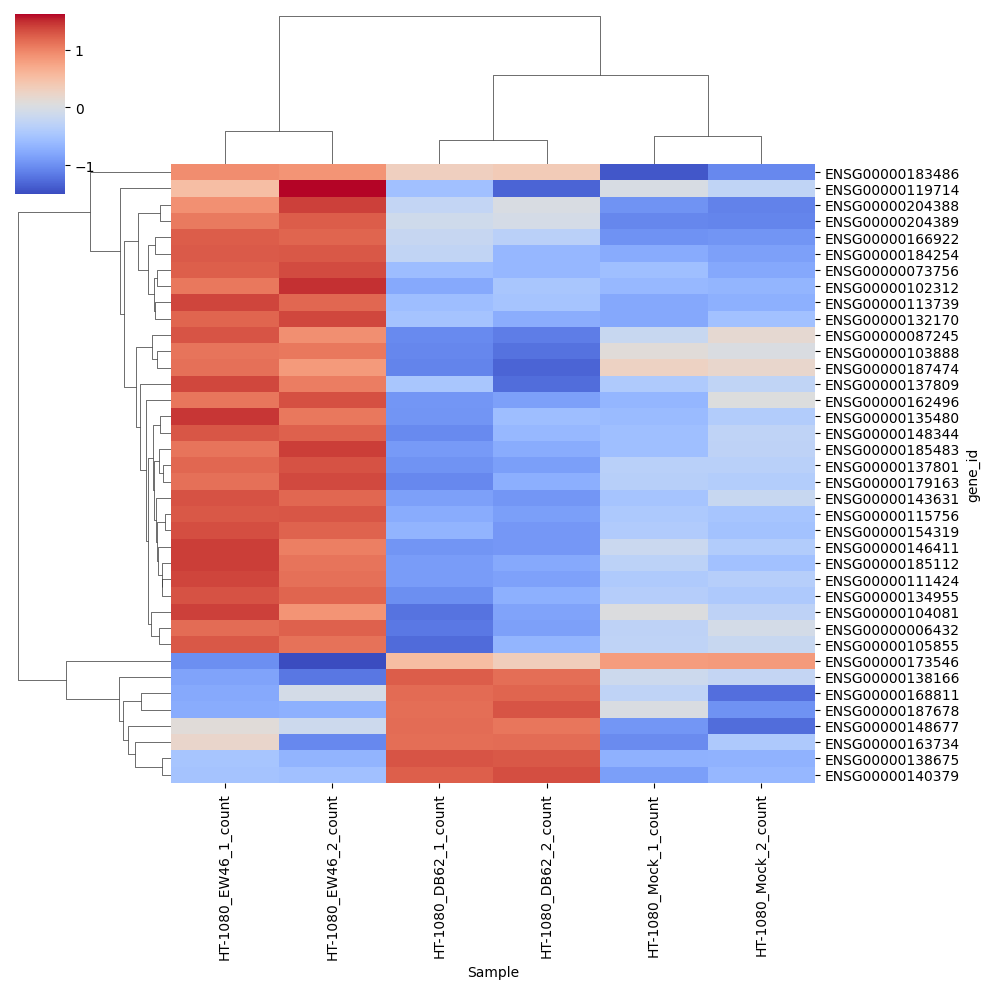

In [61]:
sns.clustermap(heatmapfull, z_score=0, cmap = "coolwarm")

In [62]:
heatmapfull.index = heatmapfull.index.map(mapper.mapper)

In [63]:
#if you want to make a CSV list of genes
#heatmapfull
#heatmapfull.to_csv('heatmap.csv')

'DB62 V EW46'

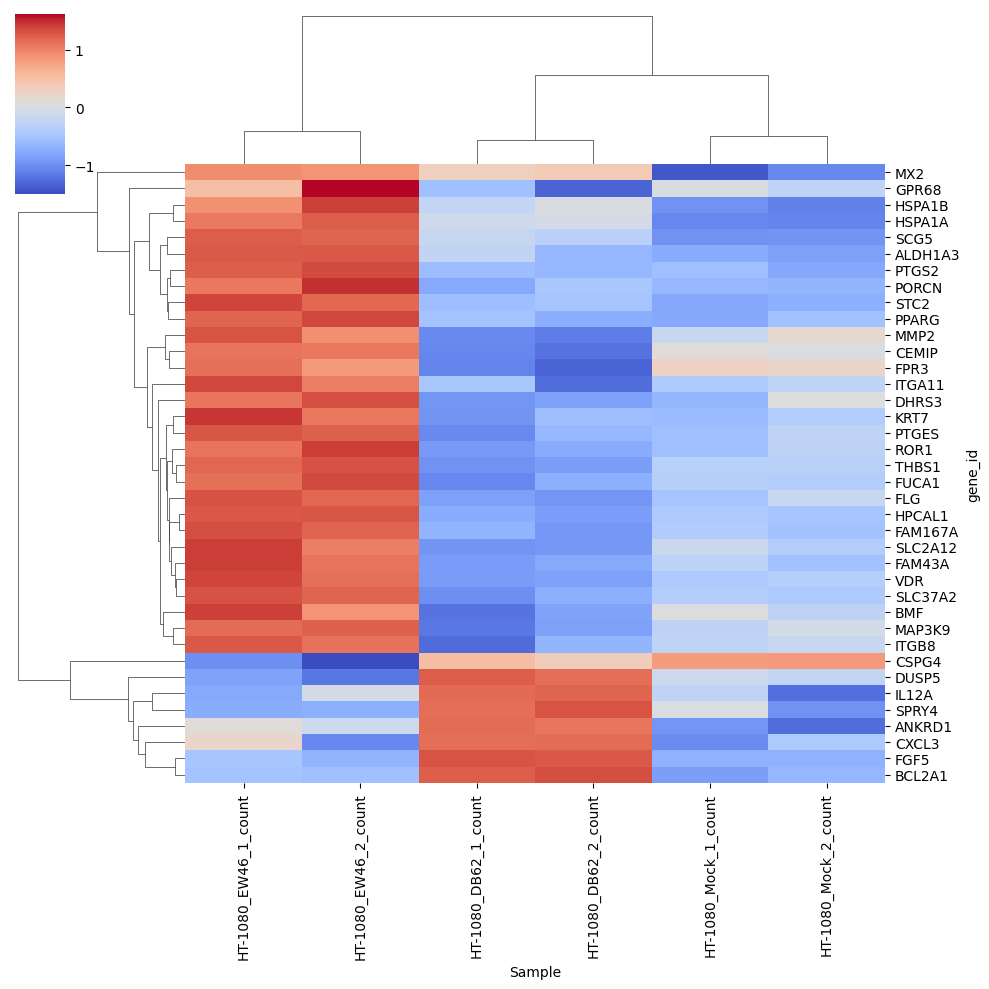

In [64]:
labeledheatmapfull = sns.clustermap(heatmapfull, z_score=0, cmap = "coolwarm", figsize=(10,10))
'''DB62 V EW46'''

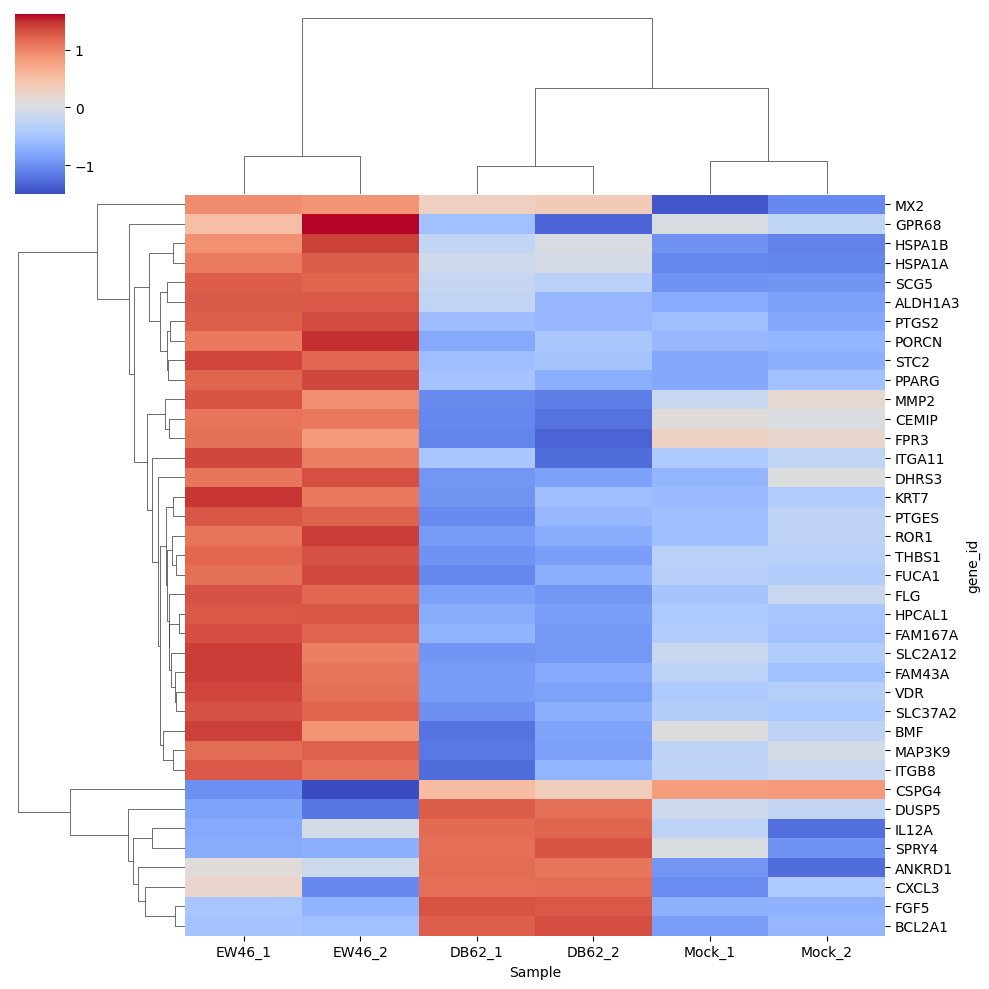

In [65]:
finalheatmapfull = pd.DataFrame(dds_sigs1.layers["log1p"].T, index=dds_sigs1.var_names, columns=dds_sigs1.obs_names)
finalheatmapfull.index = finalheatmapfull.index.map(mapper.mapper)

rename_map = {
    'HT-1080_Mock_1_count': 'Mock_1',
    'HT-1080_Mock_2_count': 'Mock_2',
    'HT-1080_DB62_1_count': 'DB62_1',
    'HT-1080_DB62_2_count': 'DB62_2',
    'HT-1080_EW46_1_count': 'EW46_1',
    'HT-1080_EW46_2_count': 'EW46_2'
}
finalheatmapfull.rename(columns=rename_map, inplace=True)

finallabeledheatmapfull = sns.clustermap(finalheatmapfull, z_score=0, cmap = "coolwarm", figsize=(10,10))
finallabeledheatmapfull

This is where full volcano plot starts

In [66]:
import matplotlib.pyplot as plt

In [67]:
cleanedsigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000006432,105.414660,-1.440988,0.235173,-6.127364,8.934702e-10,8.497987e-08,MAP3K9
ENSG00000073756,82.675863,-2.683584,0.289616,-9.266015,1.932301e-20,1.092502e-17,PTGS2
ENSG00000087245,818.202948,-1.007344,0.102586,-9.819524,9.278102e-23,7.263327e-20,MMP2
ENSG00000102312,411.942063,-1.110614,0.130711,-8.496692,1.950695e-17,6.015825e-15,PORCN
ENSG00000103888,134.535498,-1.276477,0.207879,-6.140492,8.226632e-10,7.973565e-08,CEMIP
ENSG00000104081,76.598172,-1.272240,0.276671,-4.598383,4.257836e-06,1.823084e-04,BMF
ENSG00000105855,61.578427,-1.605267,0.309129,-5.192870,2.070767e-07,1.232409e-05,ITGB8
ENSG00000111424,287.676796,-1.047042,0.144357,-7.253165,4.071449e-13,7.143989e-11,VDR
ENSG00000113739,957.005826,-1.670328,0.097125,-17.197740,2.760904e-66,9.365907e-63,STC2


In [71]:
#have to make cleanedsigs into a csv file to interact with gene_id
cleanedsigs.to_csv('cleanedsigs.csv')

In [72]:
volcano1 = pd.read_csv('cleanedsigs.csv')

In [73]:
#drop gene_id column
volcanocleanfull1 = volcano1.drop(['gene_id', 'baseMean', 'lfcSE', 'stat', 'padj'], axis=1)
volcanocleanfull = volcanocleanfull1.rename(columns={'Symbol': 'Gene'})
volcanocleanfullfinal = volcanocleanfull[['Gene', 'log2FoldChange', 'pvalue']].copy()
volcanocleanfullfinal #final dataframe used for generating full volcano plot

,Gene,log2FoldChange,pvalue
0,MAP3K9,-1.440988,8.934702e-10
1,PTGS2,-2.683584,1.932301e-20
2,MMP2,-1.007344,9.278102e-23
3,PORCN,-1.110614,1.950695e-17
4,CEMIP,-1.276477,8.226632e-10
5,BMF,-1.272240,4.257836e-06
6,ITGB8,-1.605267,2.070767e-07
7,VDR,-1.047042,4.071449e-13
8,STC2,-1.670328,2.760904e-66
9,HPCAL1,-1.290609,1.727962e-98


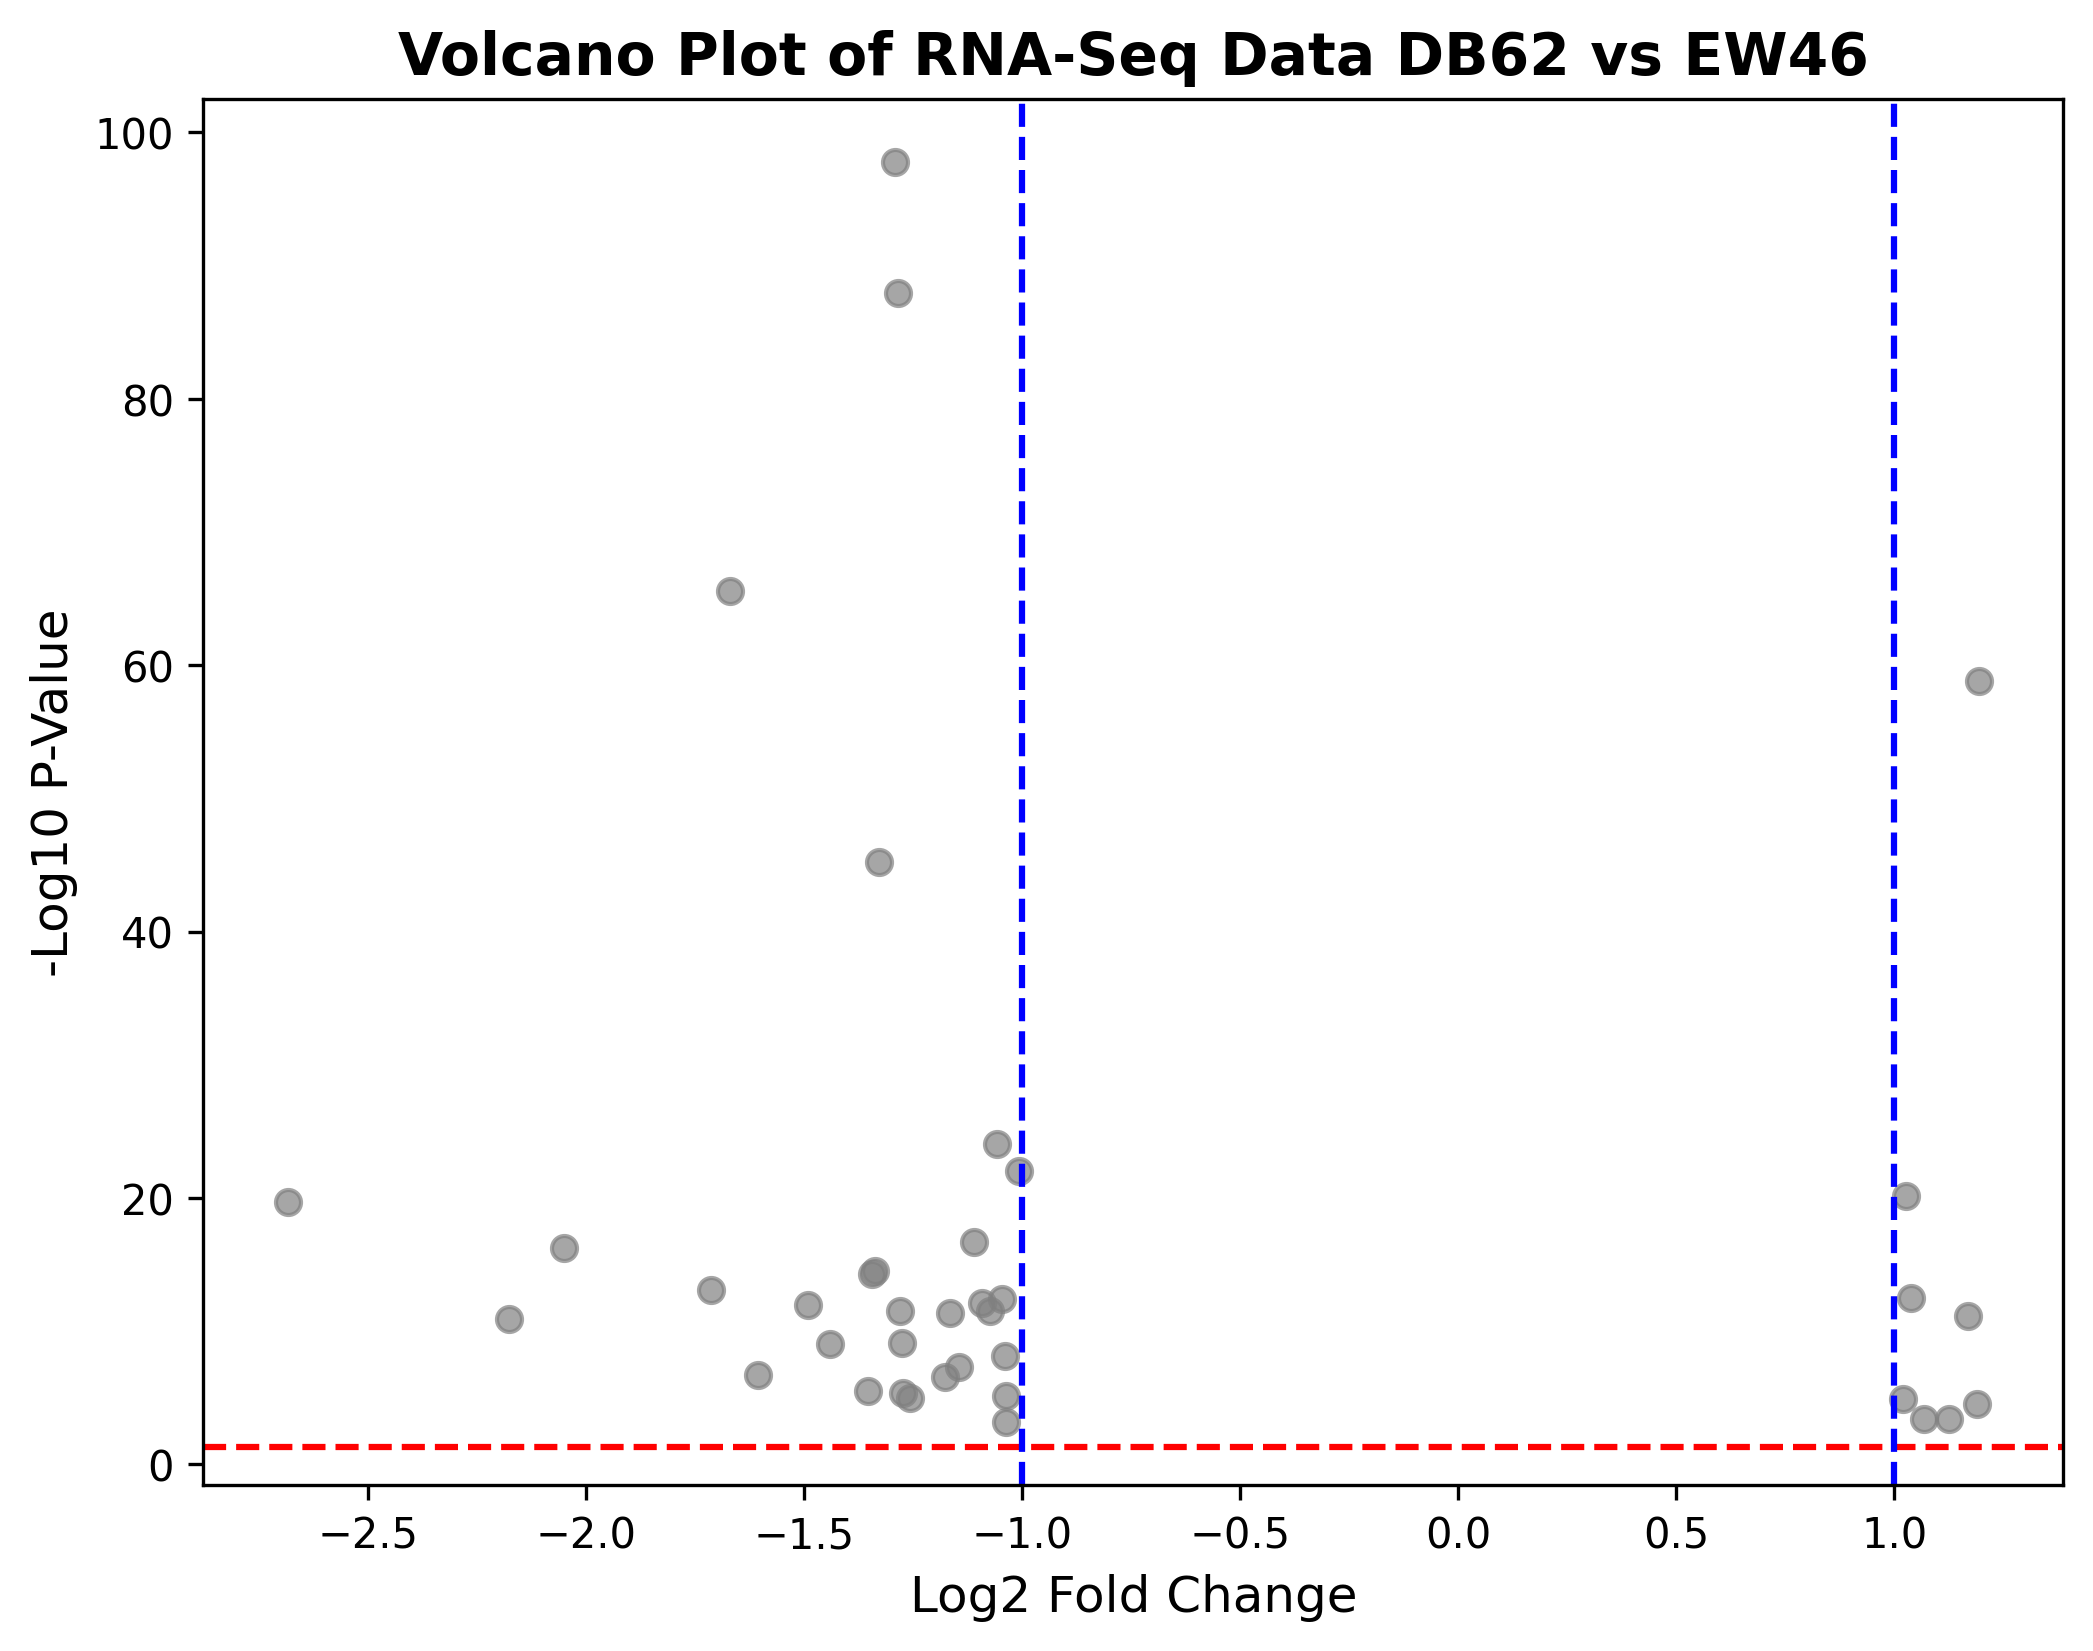

In [75]:
#set figure size and plot
plt.figure(figsize=(8,6), dpi=300)
volcanocleanfullfinal["NegLog10Pvalue"] = -np.log10(volcanocleanfullfinal["pvalue"])
plt.scatter(volcanocleanfullfinal["log2FoldChange"], volcanocleanfullfinal["NegLog10Pvalue"], color = 'gray', alpha=0.7)
plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-Log10 P-Value", fontsize=12)
plt.title("Volcano Plot of RNA-Seq Data DB62 vs EW46", fontsize=14, fontweight='bold')
plt.axhline(y=1.3, linestyle='--', color='red')
plt.axvline(x=1, linestyle='--', color='blue')
plt.axvline(x=-1, linestyle='--', color='blue')
plt.show()

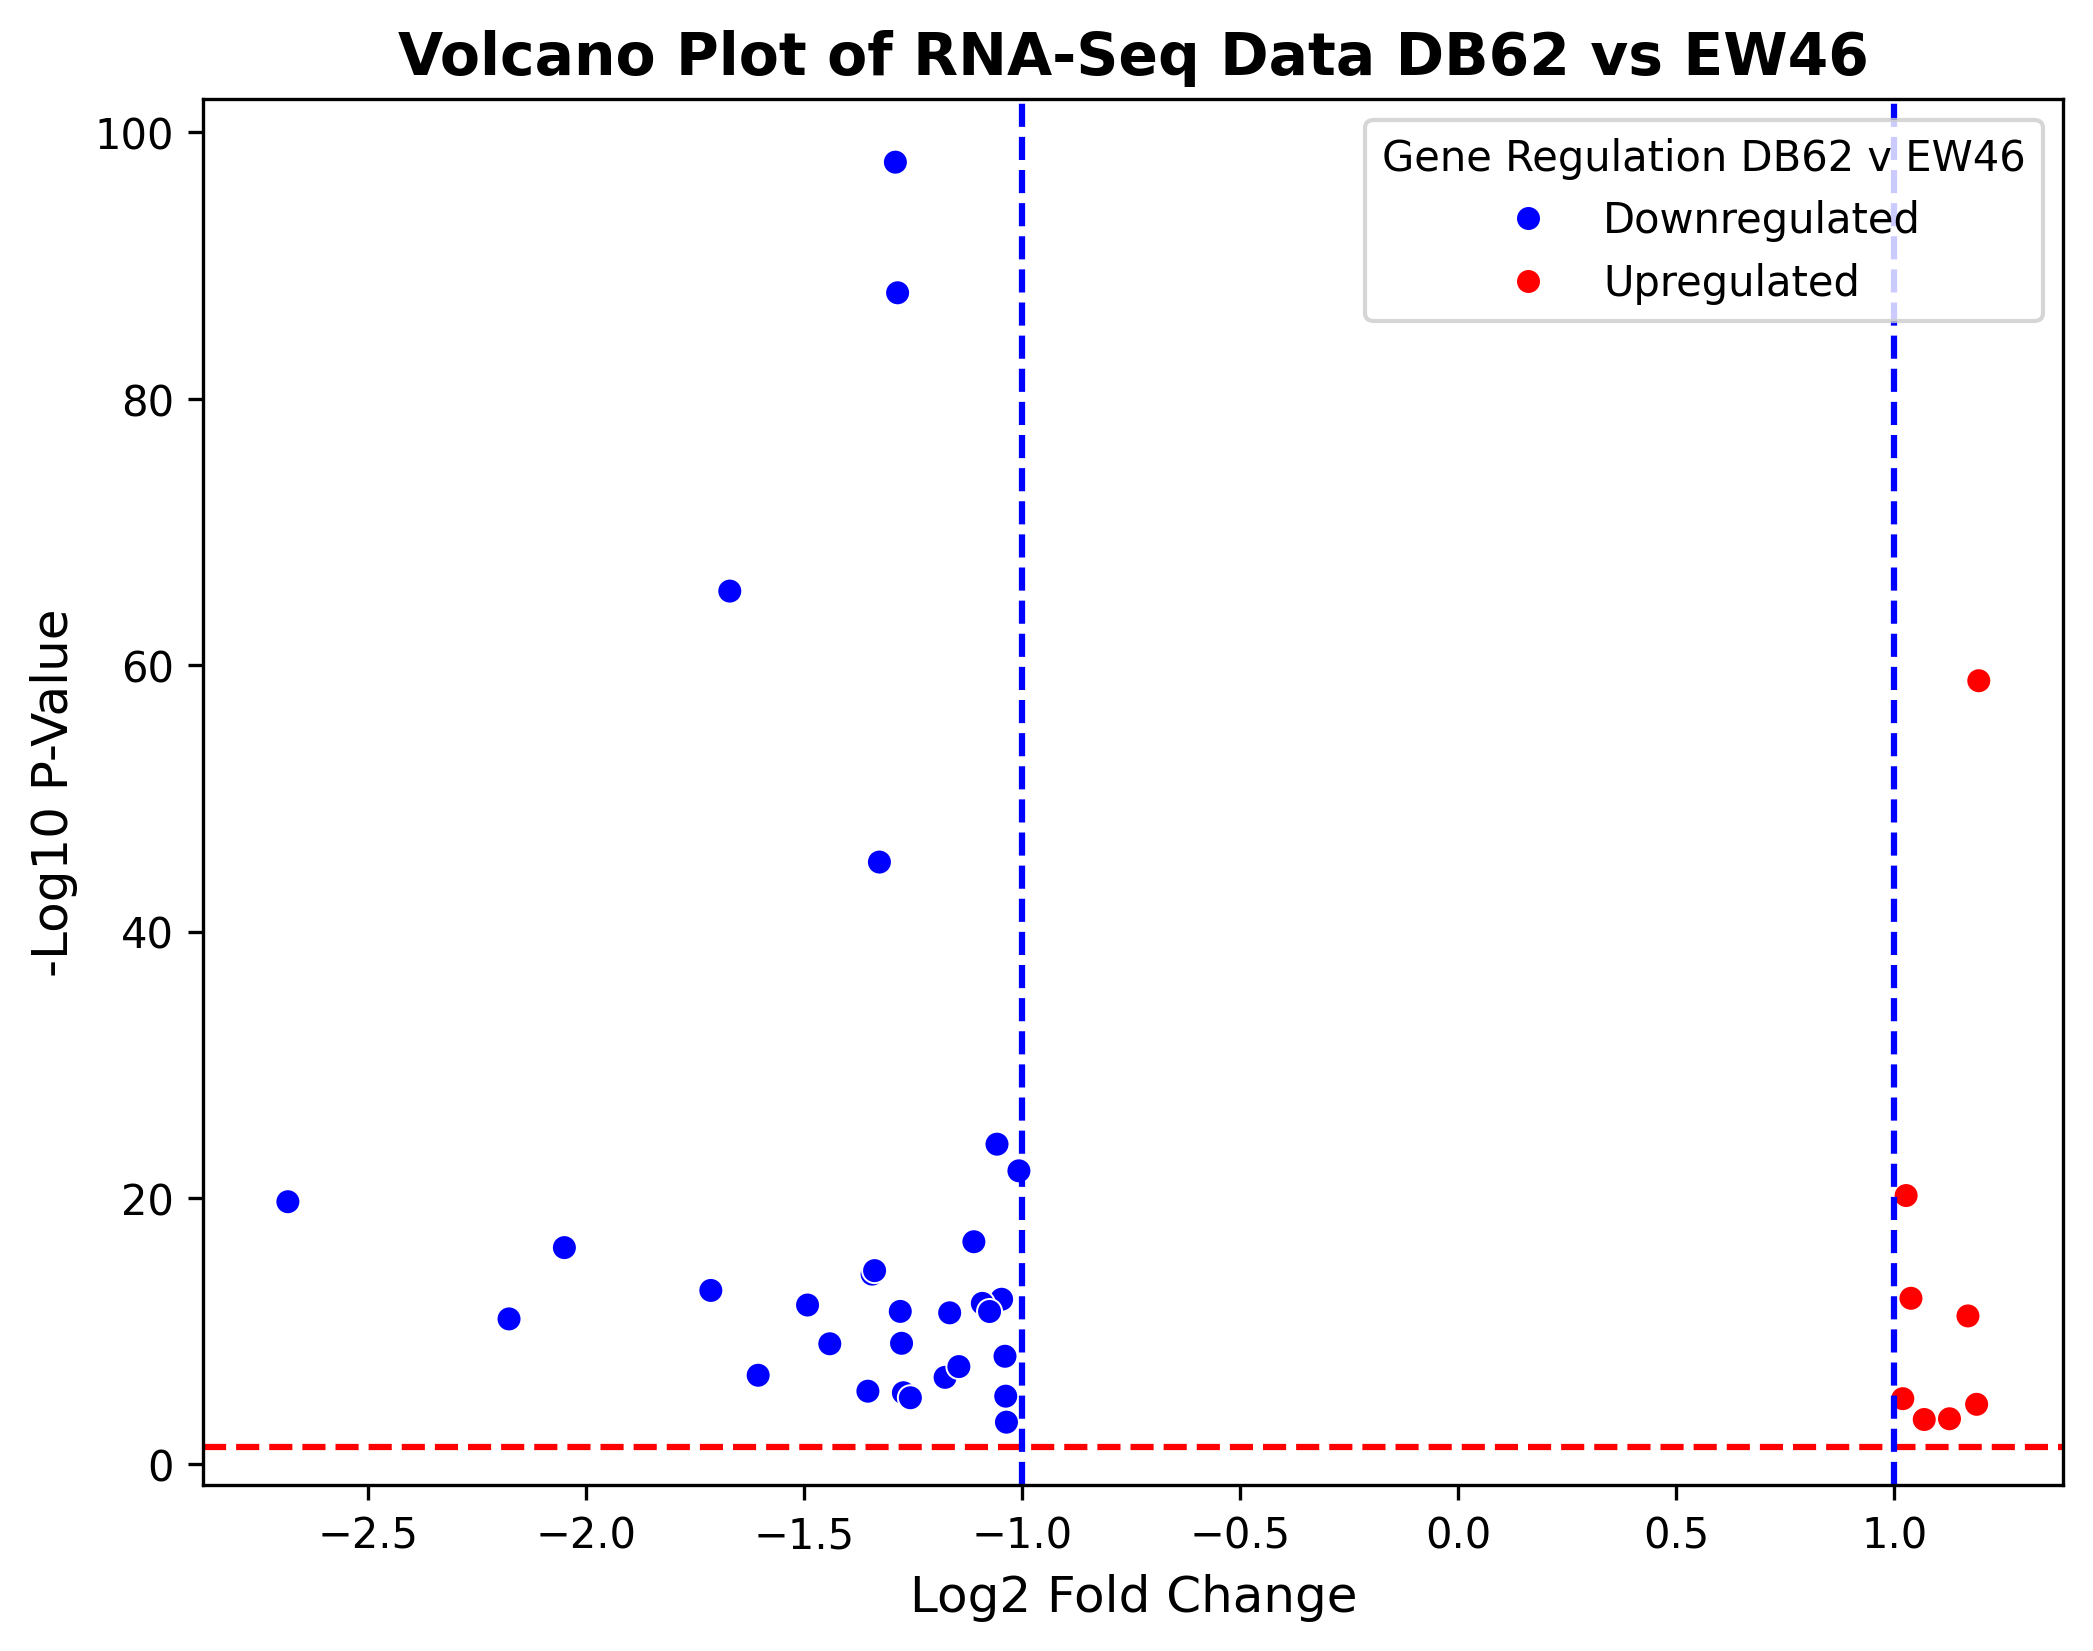

In [77]:
significant_genes = (volcanocleanfullfinal["pvalue"] < 0.05) & (abs(volcanocleanfullfinal["log2FoldChange"]) > 1)

# Calculate NegLog10Pvalue
volcanocleanfullfinal["NegLog10Pvalue"] = -np.log10(volcanocleanfullfinal["pvalue"])

# Assign regulation status based on criteria
volcanocleanfullfinal["Regulation"] = "Not Significant" # Default
volcanocleanfullfinal.loc[(volcanocleanfullfinal["pvalue"] < 0.05) & (volcanocleanfullfinal["log2FoldChange"] > 1), "Regulation"] = "Upregulated"
volcanocleanfullfinal.loc[(volcanocleanfullfinal["pvalue"] < 0.05) & (volcanocleanfullfinal["log2FoldChange"] < -1), "Regulation"] = "Downregulated"

# Define the palette to map regulation labels to colors
regulation_palette = {
    "Upregulated": "red",
    "Downregulated": "blue",
    "Not Significant": "gray"
}

#set figure size and plot
plt.figure(figsize=(8,6), dpi=300)
sns.scatterplot(data=volcanocleanfullfinal, x="log2FoldChange", y="NegLog10Pvalue", hue="Regulation", palette=regulation_palette)
plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-Log10 P-Value", fontsize=12)
plt.title("Volcano Plot of RNA-Seq Data DB62 vs EW46", fontsize=14, fontweight='bold')
plt.axhline(y=1.3, linestyle='--', color='red')
plt.axvline(x=1, linestyle='--', color='blue')
plt.axvline(x=-1, linestyle='--', color='blue')
# Let seaborn handle the legend labels automatically from the 'Regulation' column
plt.legend(title="Gene Regulation DB62 v EW46", loc="upper right")
plt.savefig("volcano_plotDB62vEW46.png", dpi=600, bbox_inches="tight")
plt.show()

Top 16 genes heatmap starts here

In [87]:
# Keep top 24 genes by lowest and highest log2foldchanges
top_12_lowest_lfc = cleanedsigs.nsmallest(12, 'log2FoldChange')
top_12_highest_lfc = cleanedsigs.nlargest(12, 'log2FoldChange')
top_24_genes_for_plots = pd.concat([top_12_lowest_lfc, top_12_highest_lfc])
top_24_genes_for_plots # Will use this dataframe for the top volcano plot as well

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Symbol
gene_id,,,,,,,
ENSG00000073756,82.675863,-2.683584,0.289616,-9.266015,1.932301e-20,1.092502e-17,PTGS2
ENSG00000143631,61.706078,-2.176483,0.321106,-6.778072,1.217901e-11,1.630865e-09,FLG
ENSG00000134955,104.943192,-2.049580,0.244650,-8.377614,5.401146e-17,1.508844e-14,SLC37A2
ENSG00000184254,110.660992,-1.713795,0.229822,-7.457063,8.847246e-14,1.698838e-11,ALDH1A3
ENSG00000113739,957.005826,-1.670328,0.097125,-17.197740,2.760904e-66,9.365907e-63,STC2
ENSG00000105855,61.578427,-1.605267,0.309129,-5.192870,2.070767e-07,1.232409e-05,ITGB8
ENSG00000137809,155.684618,-1.492011,0.209645,-7.116862,1.104122e-12,1.812363e-10,ITGA11
ENSG00000006432,105.414660,-1.440988,0.235173,-6.127364,8.934702e-10,8.497987e-08,MAP3K9
ENSG00000187474,69.404080,-1.353635,0.290839,-4.654237,3.251832e-06,1.451487e-04,FPR3


In [88]:
dds_sigs = dds[:,top_24_genes_for_plots.index]
dds_sigs

View of AnnData object with n_obs × n_vars = 6 × 24
    obs: 'Condition', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: 'normed_counts', '_mu_hat', 'cooks', 'log1p'

In [89]:
smallheatmap = pd.DataFrame(dds_sigs.layers["log1p"].T, index=dds_sigs.var_names, columns=dds_sigs.obs_names)

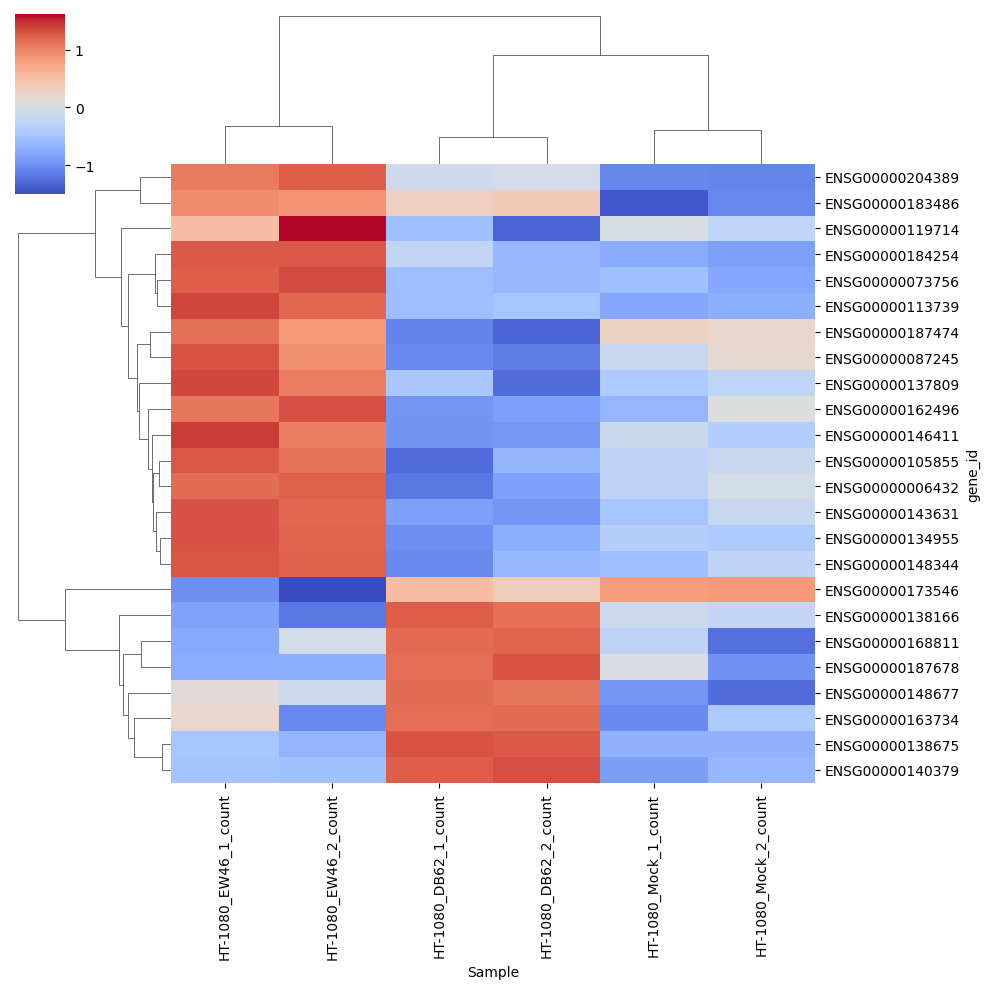

In [90]:
sns.clustermap(smallheatmap, z_score=0, cmap = "coolwarm")

In [91]:
smallheatmap.index = smallheatmap.index.map(mapper.mapper)

In [92]:
#smallheatmap
#smallheatmap.to_csv('smallheatmap.csv')
#again only neccesary if you want a csv

'DB62 V EW46'

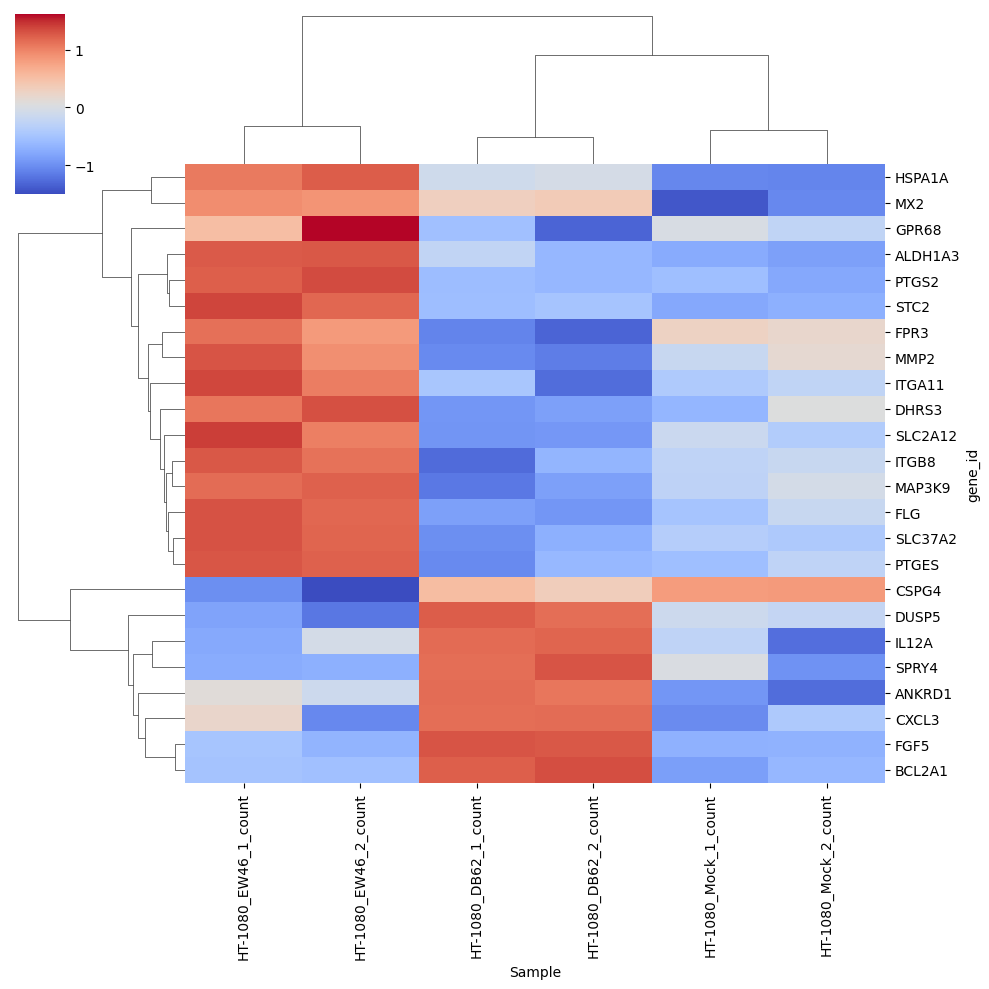

In [93]:
labeledheatmapsmall = sns.clustermap(smallheatmap, z_score=0, cmap = "coolwarm", figsize=(10,10))
'''DB62 V EW46'''

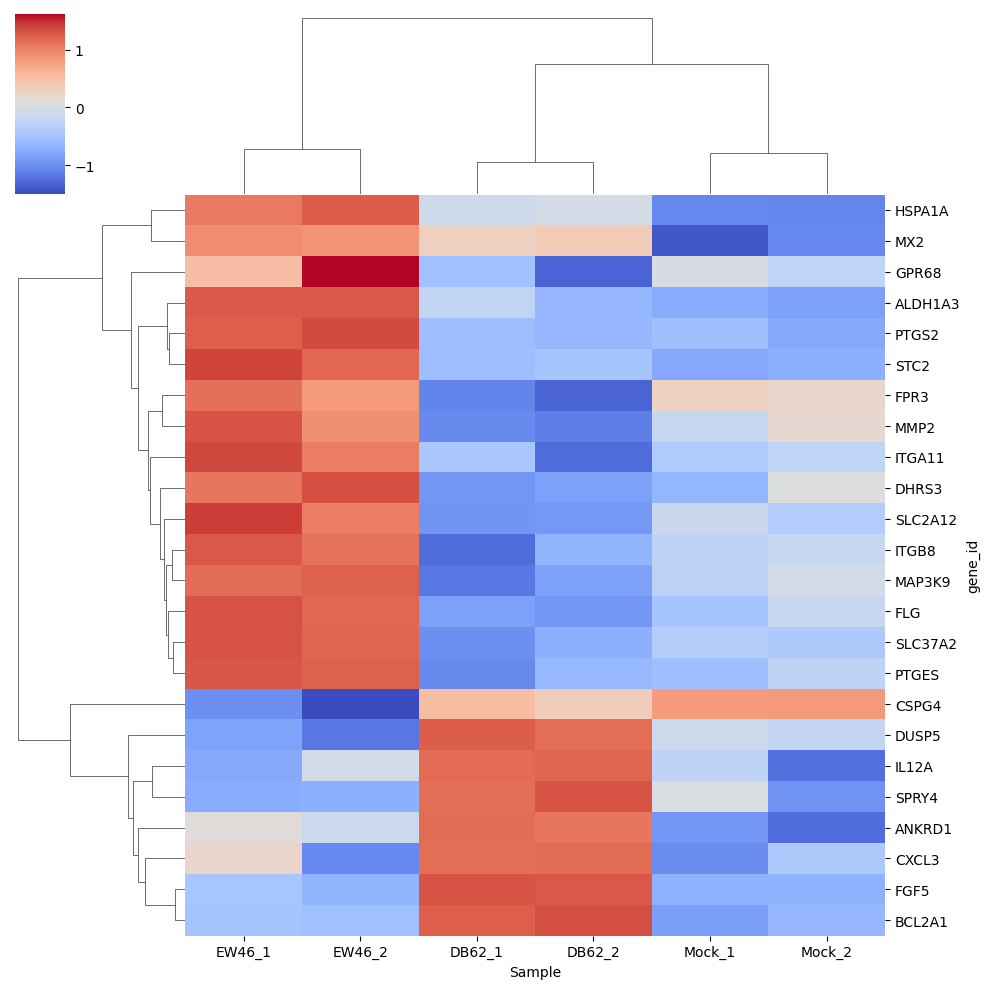

In [94]:
smallheatmap_1 = pd.DataFrame(dds_sigs.layers["log1p"].T, index=dds_sigs.var_names, columns=dds_sigs.obs_names)
smallheatmap_1.index = smallheatmap_1.index.map(mapper.mapper)

rename_map = {
    'HT-1080_Mock_1_count': 'Mock_1',
    'HT-1080_Mock_2_count': 'Mock_2',
    'HT-1080_DB62_1_count': 'DB62_1',
    'HT-1080_DB62_2_count': 'DB62_2',
    'HT-1080_EW46_1_count': 'EW46_1',
    'HT-1080_EW46_2_count': 'EW46_2'
}
smallheatmap_1.rename(columns=rename_map, inplace=True)

smallheatmaplabeledfinal = sns.clustermap(smallheatmap_1, z_score=0, cmap = "coolwarm", figsize=(10,10))
smallheatmaplabeledfinal

This is where top 16 genes volcano plot starts

In [98]:
#Have to Convert top 24 genes to csv file
top_24_genes_for_plots.to_csv('top_24_genes_for_plots.csv')

In [99]:
smallvolcano1 = pd.read_csv('top_24_genes_for_plots.csv')

In [100]:
#drop gene_id column
smallvolcanocleanfull1 = smallvolcano1.drop(['gene_id', 'baseMean', 'lfcSE', 'stat', 'padj'], axis=1)
smallvolcanocleanfull = smallvolcanocleanfull1.rename(columns={'Symbol': 'Gene'})
smallvolcanocleanfullfinal = smallvolcanocleanfull[['Gene', 'log2FoldChange', 'pvalue']].copy()
smallvolcanocleanfullfinal #final dataframe used for generating small volcano plot

,Gene,log2FoldChange,pvalue
0,PTGS2,-2.683584,1.932301e-20
1,FLG,-2.176483,1.217901e-11
2,SLC37A2,-2.049580,5.401146e-17
3,ALDH1A3,-1.713795,8.847246e-14
4,STC2,-1.670328,2.760904e-66
5,ITGB8,-1.605267,2.070767e-07
6,ITGA11,-1.492011,1.104122e-12
7,MAP3K9,-1.440988,8.934702e-10
8,FPR3,-1.353635,3.251832e-06
9,PTGES,-1.343994,5.262415e-15


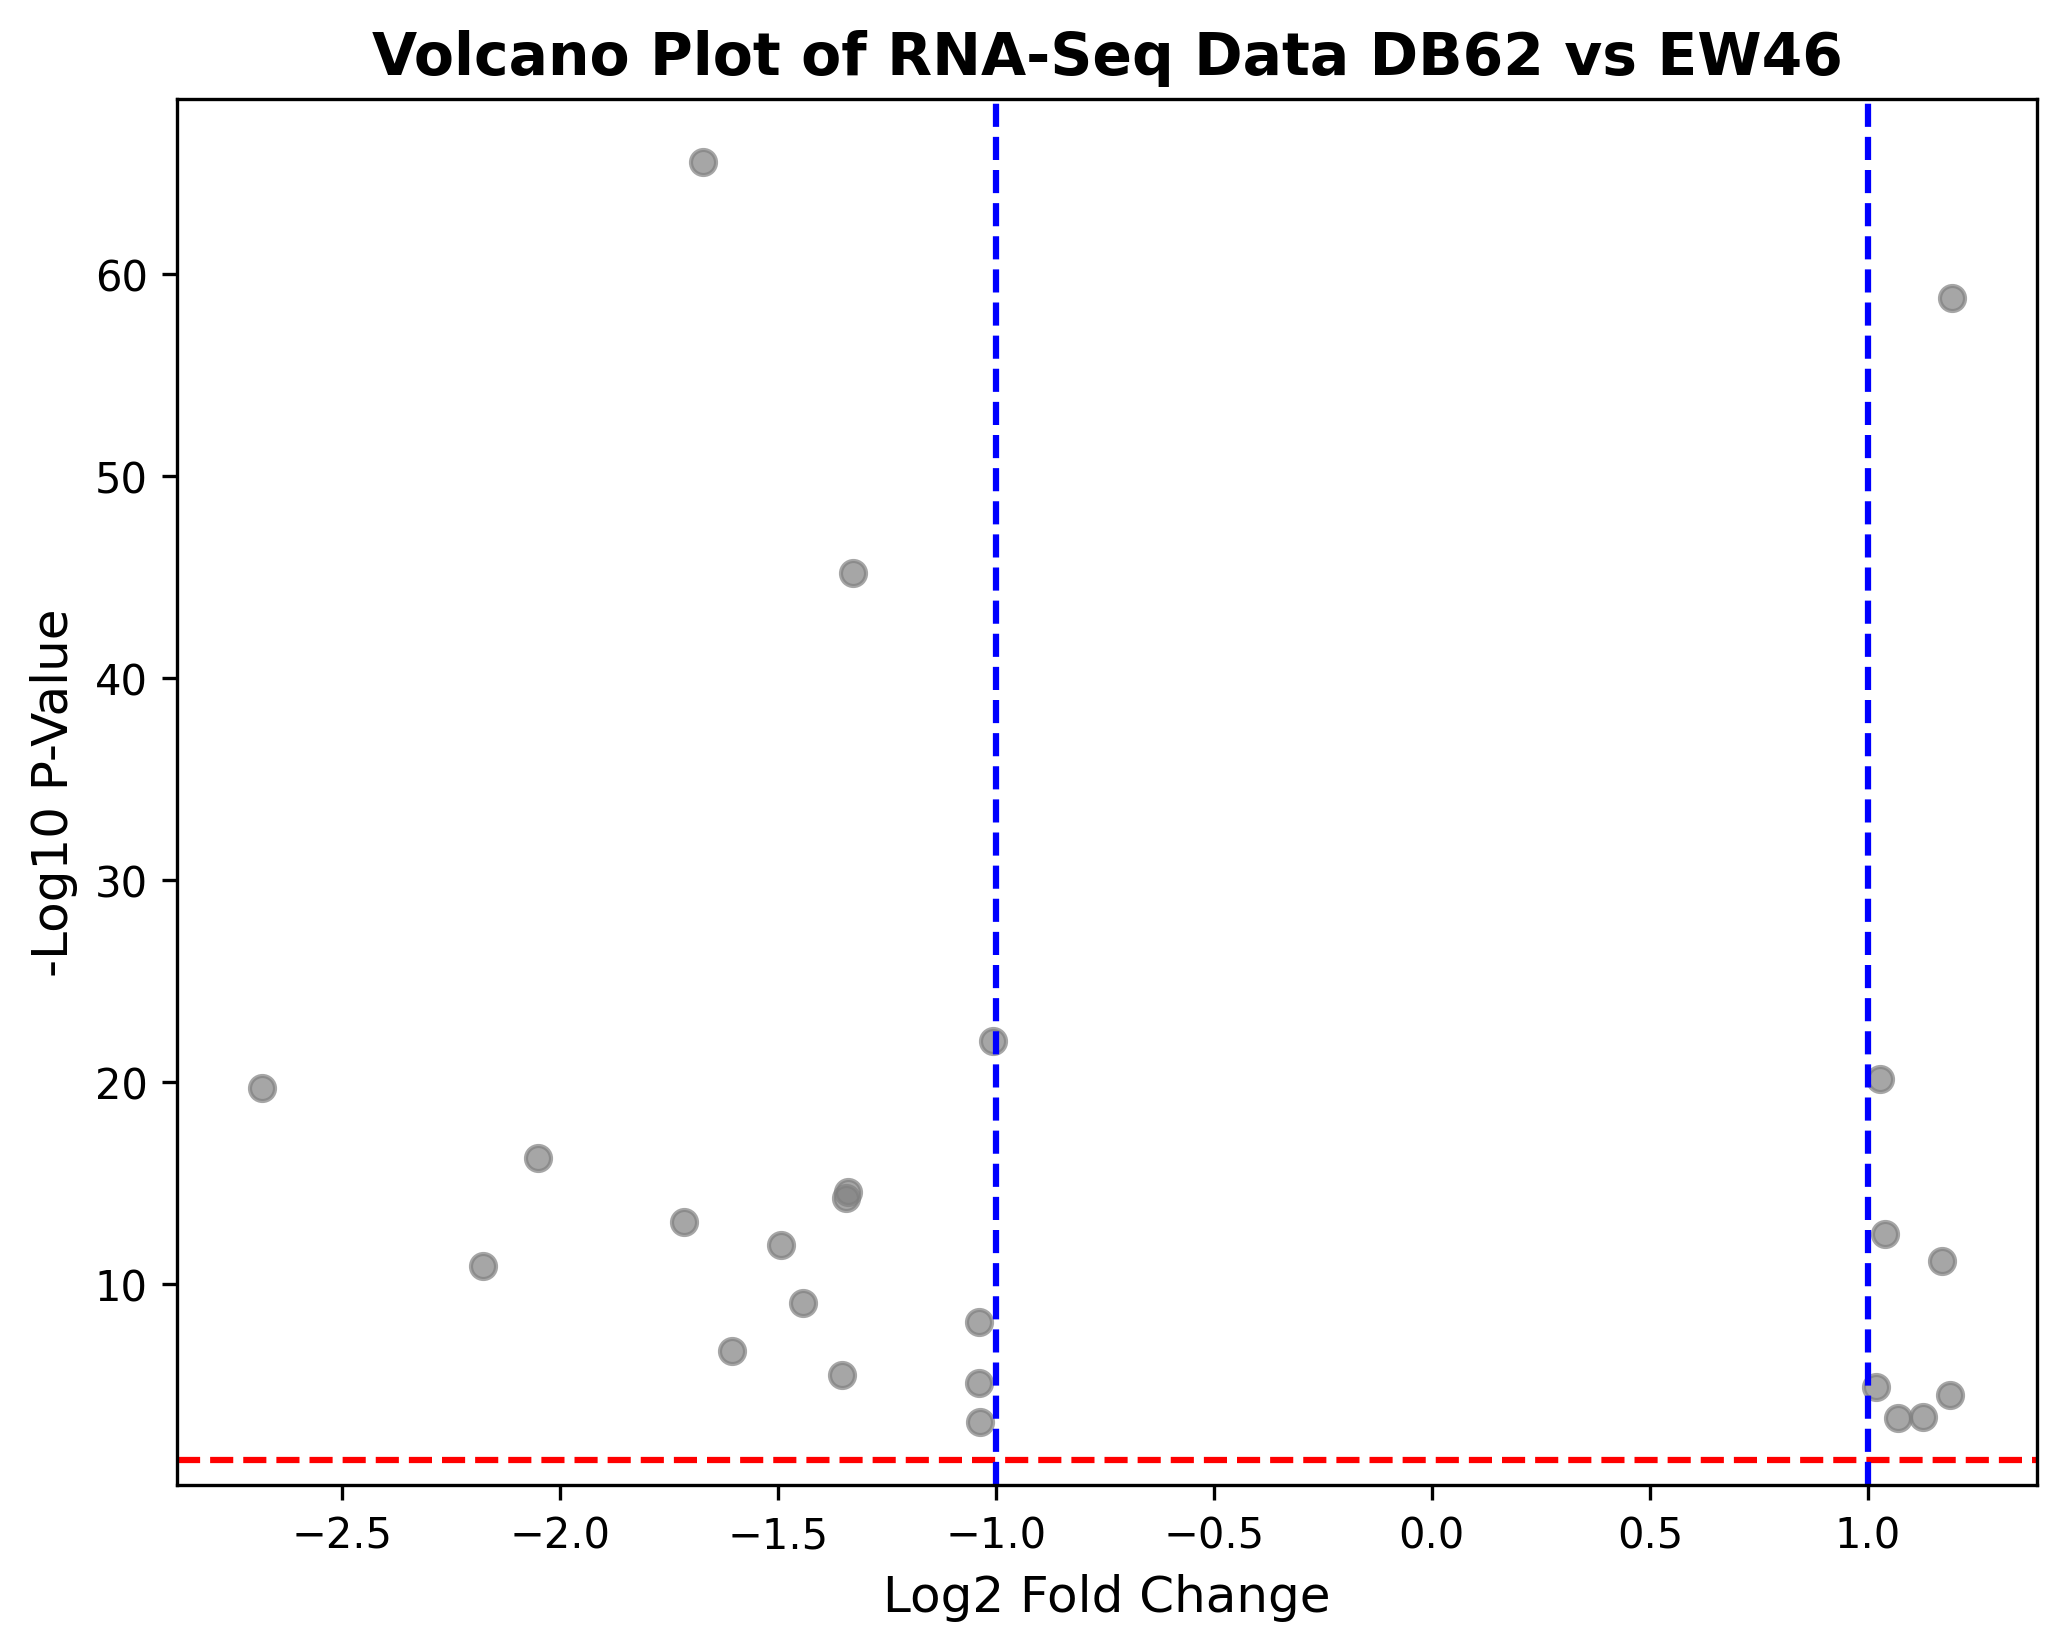

In [102]:
#set figure size and plot
plt.figure(figsize=(8,6), dpi=300)
smallvolcanocleanfullfinal["NegLog10Pvalue"] = -np.log10(smallvolcanocleanfullfinal["pvalue"])
plt.scatter(smallvolcanocleanfullfinal["log2FoldChange"], smallvolcanocleanfullfinal["NegLog10Pvalue"], color = 'gray', alpha=0.7)
plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-Log10 P-Value", fontsize=12)
plt.title("Volcano Plot of RNA-Seq Data DB62 vs EW46", fontsize=14, fontweight='bold')
plt.axhline(y=1.3, linestyle='--', color='red')
plt.axvline(x=1, linestyle='--', color='blue')
plt.axvline(x=-1, linestyle='--', color='blue')
plt.show()

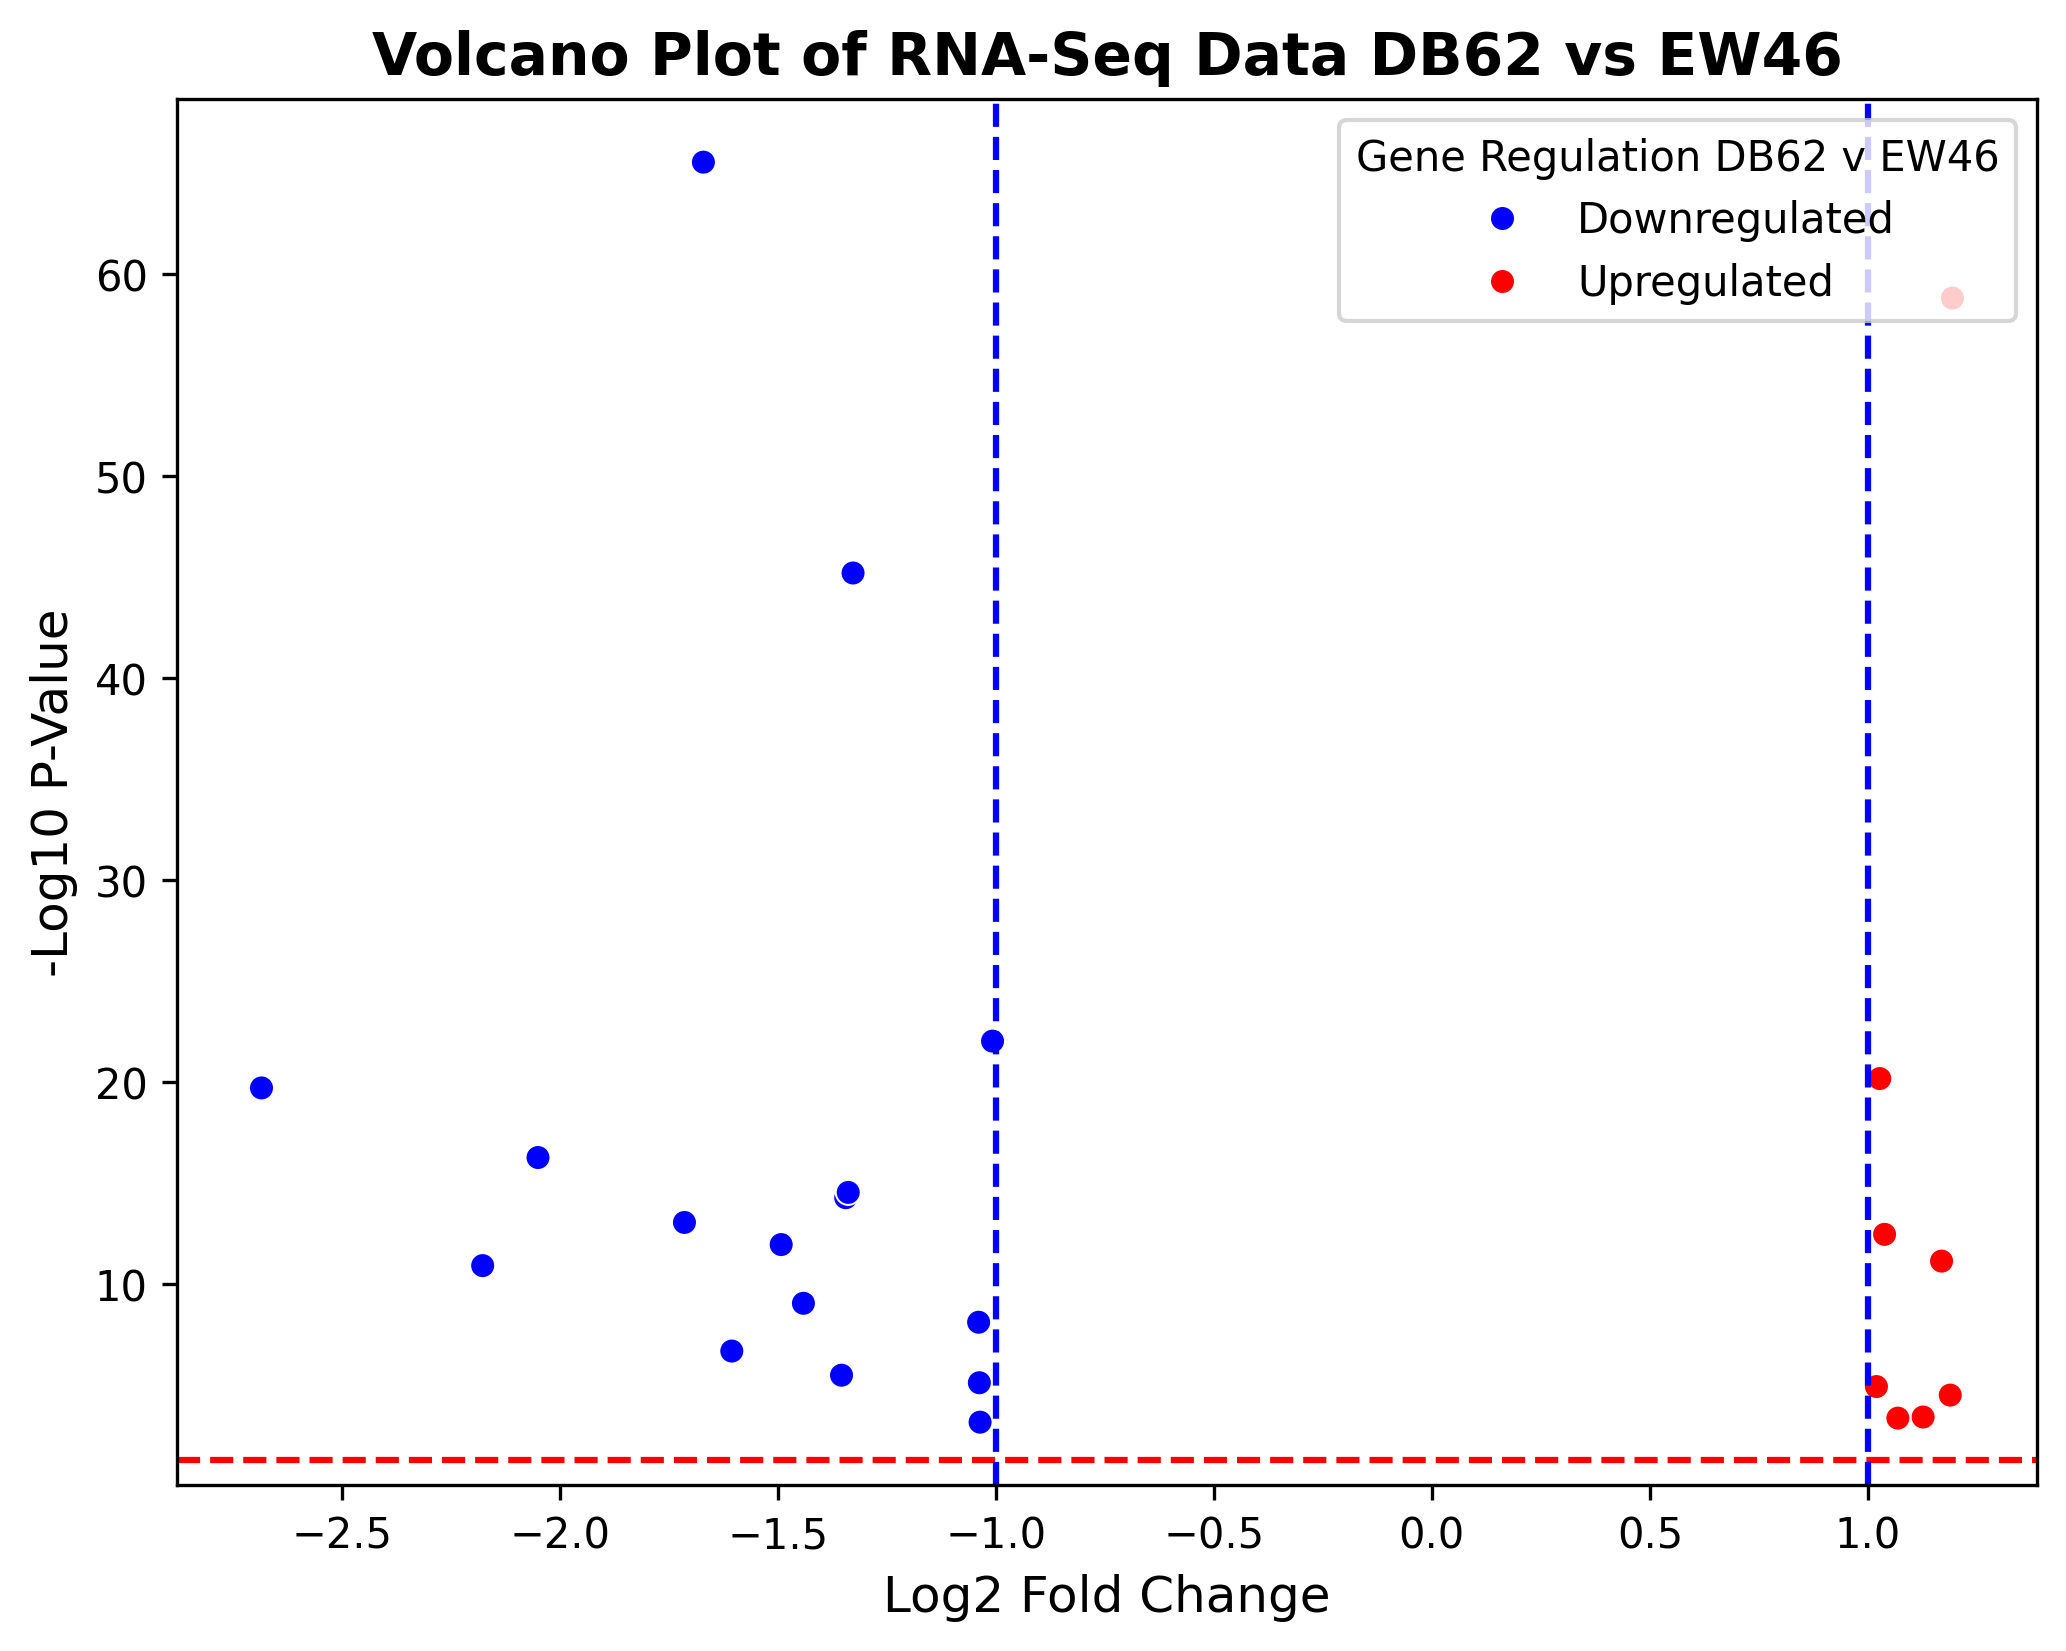

In [104]:
significant_genes = (smallvolcanocleanfullfinal["pvalue"] < 0.05) & (abs(smallvolcanocleanfullfinal["log2FoldChange"]) > 1)

# Calculate NegLog10Pvalue
smallvolcanocleanfullfinal["NegLog10Pvalue"] = -np.log10(smallvolcanocleanfullfinal["pvalue"])

# Assign regulation status based on criteria
smallvolcanocleanfullfinal["Regulation"] = "Not Significant" # Default
smallvolcanocleanfullfinal.loc[(smallvolcanocleanfullfinal["pvalue"] < 0.05) & (smallvolcanocleanfullfinal["log2FoldChange"] > 1), "Regulation"] = "Upregulated"
smallvolcanocleanfullfinal.loc[(smallvolcanocleanfullfinal["pvalue"] < 0.05) & (smallvolcanocleanfullfinal["log2FoldChange"] < -1), "Regulation"] = "Downregulated"

# Define the palette to map regulation labels to colors
regulation_palette = {
    "Upregulated": "red",
    "Downregulated": "blue",
    "Not Significant": "gray"
}

#set figure size and plot
plt.figure(figsize=(8,6), dpi=300)
sns.scatterplot(data=smallvolcanocleanfullfinal, x="log2FoldChange", y="NegLog10Pvalue", hue="Regulation", palette=regulation_palette)
plt.xlabel("Log2 Fold Change", fontsize=12)
plt.ylabel("-Log10 P-Value", fontsize=12)
plt.title("Volcano Plot of RNA-Seq Data DB62 vs EW46", fontsize=14, fontweight='bold')
plt.axhline(y=1.3, linestyle='--', color='red')
plt.axvline(x=1, linestyle='--', color='blue')
plt.axvline(x=-1, linestyle='--', color='blue')
# Let seaborn handle the legend labels automatically from the 'Regulation' column
plt.legend(title="Gene Regulation DB62 v EW46", loc="upper right")
plt.savefig("smallvolcano_plotDB62vEW46.png", dpi=600, bbox_inches="tight")
plt.show()